In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## load data
df = pd.read_csv('../dataset/taxi_tripdata.csv')
df.head()

/var/folders/8n/4tmx7gjx57j_gn5wps411qp40000gn/T/ipykernel_32585/4290134157.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../dataset/taxi_tripdata.csv')


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,1.0,2021-07-01 00:30:52,2021-07-01 00:35:36,N,1.0,74,168,1.0,1.20,6.0,0.5,0.5,0.00,0.0,NaN,0.3,7.30,2.0,1.0,0.0
1,2.0,2021-07-01 00:25:36,2021-07-01 01:01:31,N,1.0,116,265,2.0,13.69,42.0,0.5,0.5,0.00,0.0,NaN,0.3,43.30,2.0,1.0,0.0
2,2.0,2021-07-01 00:05:58,2021-07-01 00:12:00,N,1.0,97,33,1.0,0.95,6.5,0.5,0.5,2.34,0.0,NaN,0.3,10.14,1.0,1.0,0.0
3,2.0,2021-07-01 00:41:40,2021-07-01 00:47:23,N,1.0,74,42,1.0,1.24,6.5,0.5,0.5,0.00,0.0,NaN,0.3,7.80,2.0,1.0,0.0
4,2.0,2021-07-01 00:51:32,2021-07-01 00:58:46,N,1.0,42,244,1.0,1.10,7.0,0.5,0.5,0.00,0.0,NaN,0.3,8.30,2.0,1.0,0.0


In [3]:
## kiểm tra cấu trúc data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83691 entries, 0 to 83690
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               51173 non-null  float64
 1   lpep_pickup_datetime   83691 non-null  object 
 2   lpep_dropoff_datetime  83691 non-null  object 
 3   store_and_fwd_flag     51173 non-null  object 
 4   RatecodeID             51173 non-null  float64
 5   PULocationID           83691 non-null  int64  
 6   DOLocationID           83691 non-null  int64  
 7   passenger_count        51173 non-null  float64
 8   trip_distance          83691 non-null  float64
 9   fare_amount            83691 non-null  float64
 10  extra                  83691 non-null  float64
 11  mta_tax                83691 non-null  float64
 12  tip_amount             83691 non-null  float64
 13  tolls_amount           83691 non-null  float64
 14  ehail_fee              0 non-null      float64
 15  im

In [4]:
## thống kê mô tả
### count: số lượng giá trị không null
### mean: giá trị trung bình
### std: độ lệch chuẩn
### min: giá trị nhỏ nhất
### 25%: giá trị tại vị trí 25% của dữ liệu
### 50%: giá trị tại vị trí 50% của dữ liệu (median)
### 75%: giá trị tại vị trí 75% của dữ liệu
### max: giá trị lớn nhất
df.describe()

,VendorID,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
count,51173.000000,51173.000000,83691.000000,83691.000000,51173.000000,83691.000000,83691.000000,83691.000000,83691.000000,83691.000000,83691.000000,0.0,83691.000000,83691.000000,51173.000000,51173.000000,51173.000000
mean,1.851113,1.159244,108.362572,133.270005,1.307858,194.354699,20.388305,1.156707,0.293562,1.058618,0.624529,NaN,0.297745,24.204836,1.421726,1.034393,0.642815
std,0.355981,0.773260,70.370170,77.216791,0.984362,4405.549221,15.583552,1.367897,0.247773,2.368771,1.990481,NaN,0.031219,17.262183,0.511146,0.182239,1.164219
min,1.000000,1.000000,3.000000,1.000000,0.000000,0.000000,-150.000000,-4.500000,-0.500000,-1.140000,0.000000,NaN,-0.300000,-150.300000,1.000000,1.000000,-2.750000
25%,2.000000,1.000000,56.000000,69.000000,1.000000,1.350000,9.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.300000,11.760000,1.000000,1.000000,0.000000
50%,2.000000,1.000000,75.000000,132.000000,1.000000,2.760000,16.000000,0.500000,0.500000,0.000000,0.000000,NaN,0.300000,19.800000,1.000000,1.000000,0.000000
75%,2.000000,1.000000,166.000000,205.000000,1.000000,6.200000,26.830000,2.750000,0.500000,1.660000,0.000000,NaN,0.300000,31.300000,2.000000,1.000000,0.000000
max,2.000000,5.000000,265.000000,265.000000,32.000000,260517.930000,480.000000,8.250000,0.500000,87.710000,30.050000,NaN,0.300000,480.310000,5.000000,2.000000,2.750000


In [5]:
## check missing values
df.isna().sum()

VendorID                 32518
lpep_pickup_datetime         0
lpep_dropoff_datetime        0
store_and_fwd_flag       32518
RatecodeID               32518
PULocationID                 0
DOLocationID                 0
passenger_count          32518
trip_distance                0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
ehail_fee                83691
improvement_surcharge        0
total_amount                 0
payment_type             32518
trip_type                32518
congestion_surcharge     32518
dtype: int64

In [6]:
## convert object to datatime
df['lpep_dropoff_datetime'] = pd.to_datetime(df['lpep_dropoff_datetime'])
df['lpep_pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83691 entries, 0 to 83690
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               51173 non-null  float64       
 1   lpep_pickup_datetime   83691 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  83691 non-null  datetime64[ns]
 3   store_and_fwd_flag     51173 non-null  object        
 4   RatecodeID             51173 non-null  float64       
 5   PULocationID           83691 non-null  int64         
 6   DOLocationID           83691 non-null  int64         
 7   passenger_count        51173 non-null  float64       
 8   trip_distance          83691 non-null  float64       
 9   fare_amount            83691 non-null  float64       
 10  extra                  83691 non-null  float64       
 11  mta_tax                83691 non-null  float64       
 12  tip_amount             83691 non-null  float64       
 13  t

In [8]:
## create trip duration
### tính toán thời gian di chuyển của một chuyến taxi
df['trip_duration'] = (df['lpep_dropoff_datetime'] - 
                      df['lpep_pickup_datetime']).dt.total_seconds()

In [9]:
df['trip_duration'].head()

0     284.0
1    2155.0
2     362.0
3     343.0
4     434.0
Name: trip_duration, dtype: float64

In [10]:
# feature: trip speed
## traffic efficiency: tốc độ trung bình của chuyến đi
## outliers: những chuyến đi có tốc độ quá cao hoặc quá thấp có thể là dữ liệu lỗi hoặc những chuyến đi đặc biệt
df['trip_speed'] = df["trip_distance"] / (df['trip_duration'] / 3600)  # miles per hour
df['trip_speed'].head()

0    15.211268
1    22.869606
2     9.447514
3    13.014577
4     9.124424
Name: trip_speed, dtype: float64

In [11]:
## remove invalid trips
df = df[df['trip_distance'] > 0]
df = df[df['trip_duration'] > 0]
df = df[df['trip_speed'] < 120]  # loại bỏ những chuyến đi có tốc độ quá cao

In [13]:
## create tempotal features
df['pickup_hour'] = df['lpep_pickup_datetime'].dt.hour
print(df['pickup_hour'].head())
df['pickup_day'] = df['lpep_pickup_datetime'].dt.dayofweek
print(df['pickup_day'].head())
df['pickup_month'] = df['lpep_pickup_datetime'].dt.month
print(df['pickup_month'].head())

0    0
1    0
2    0
3    0
4    0
Name: pickup_hour, dtype: int32
0    3
1    3
2    3
3    3
4    3
Name: pickup_day, dtype: int32
0    7
1    7
2    7
3    7
4    7
Name: pickup_month, dtype: int32


In [16]:
## Demand by hour, day, month
## gom dữ liệu theo giờ, đếm số trip (chuyến xe)
## mobility pattern analysis
hourly = df.groupby('pickup_hour').size()
daily = df.groupby('pickup_day').size()
monthly = df.groupby('pickup_month').size()

Text(0.5, 1.0, 'Taxi Demand by Hour')

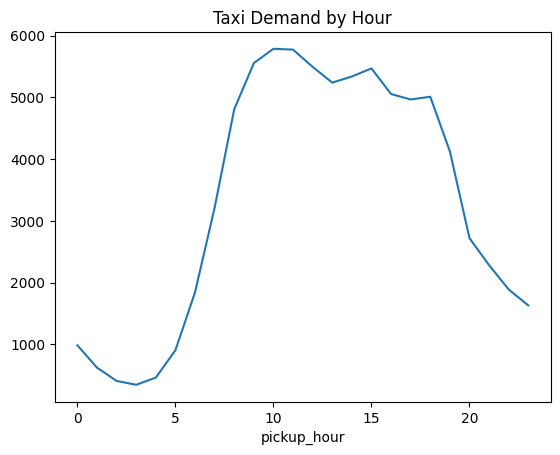

In [18]:
## visualization
sns.lineplot(x=hourly.index, y=hourly.values)
plt.title('Taxi Demand by Hour')

Text(0.5, 1.0, 'Taxi Demand by Day of Week')

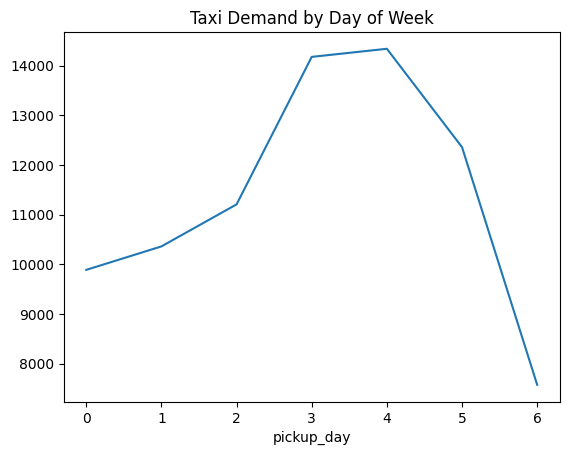

In [19]:
sns.lineplot(x=daily.index, y=daily.values)
plt.title('Taxi Demand by Day of Week')

Text(0.5, 1.0, 'Taxi Demand by Month')

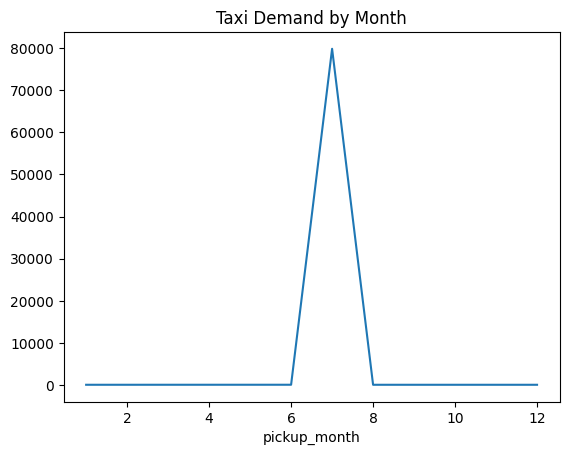

In [20]:
sns.lineplot(x=monthly.index, y=monthly.values)
plt.title('Taxi Demand by Month')

# Spatial Analysis

## Demand by zone

In [21]:
pickup_demand = df.groupby('PULocationID').size()
pickup_demand

PULocationID
3       117
4        22
5        25
6         6
7      1761
       ... 
261      13
262      36
263     148
264      56
265     137
Length: 252, dtype: int64

In [22]:
## load taxi zones
import geopandas as gpd
zones = gpd.read_file('../dataset/zones/taxi_zones.shp')

In [23]:
## merge demand
zones['demand'] = zones['LocationID'].map(pickup_demand)

<Axes: >

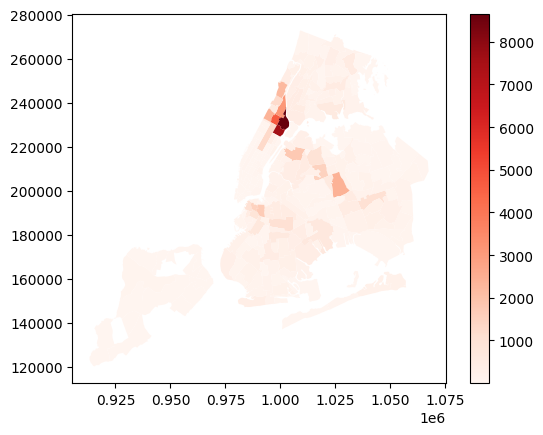

In [24]:
## plot heatmap
zones.plot(column='demand', cmap='Reds', legend=True)

# Demand forecasting

In [25]:
# trips per zone per hour
demand = df.groupby(
  ['PULocationID', 'pickup_hour']
).size().reset_index()
demand.columns = ['zone', 'hour', 'trip_count']

In [27]:
# prepare data for modeling
from sklearn.model_selection import train_test_split

X = demand[['zone', 'hour']]
y = demand['trip_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1105)

In [30]:
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
# evaluate model
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_test)
mean_absolute_error(y_test, pred)

5.459831714630127